### Import necessary libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from sklearn.utils import shuffle
from skimage.transform import resize
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

### Fetch the image data

In [4]:
cloudy = glob.glob('data/cloudy/*.jpg')
desert = glob.glob('data/desert/*.jpg')
green_area = glob.glob('data/green_area/*.jpg')
water = glob.glob('data/water/*.jpg')

In [5]:
len(cloudy)

1500

In [6]:
len(desert)

1131

In [7]:
len(green_area)

1500

In [8]:
len(water)

1500

### Store all the images inside a list and create a list with corresponding labels

In [10]:
image = []
label = []

for i in cloudy:
    img = plt.imread(i)
    image.append(img)
    label.append(0)

for i in desert:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

for i in green_area:
    img = plt.imread(i)
    image.append(img)
    label.append(2)

for i in water:
    img = plt.imread(i)
    image.append(img)
    label.append(3)

### Shuffle both images and labels

In [12]:
image,label = shuffle(image,label,random_state=100)

### Plot a few images from our shuffled list with its corresponding label

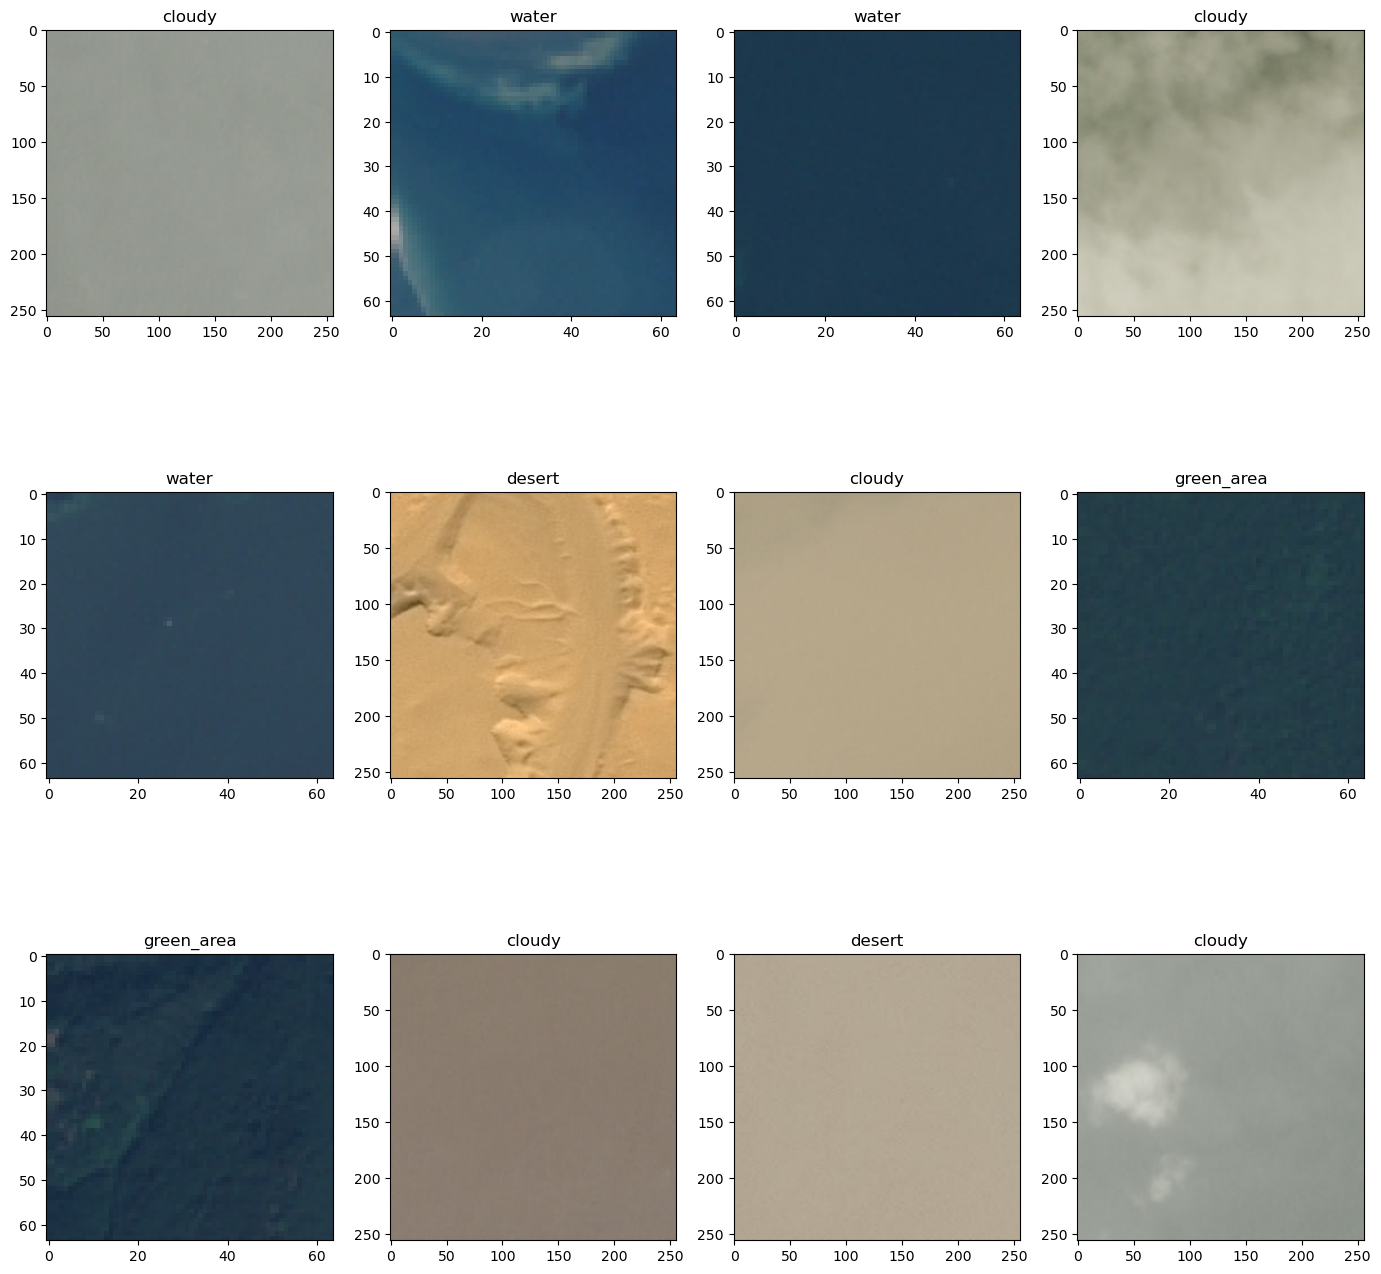

In [14]:
plt.figure(figsize=(17,17))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 0:
        plt.title('cloudy')
    elif label[i] == 1:
        plt.title('desert')
    elif label[i] == 2:
        plt.title('green_area')
    elif label[i] == 3:
        plt.title('water')

### Resize the images to 64X64

In [16]:
X  = []

for i in image:
    X.append(resize(i,(64,64,3)))

X = np.array(X)

### Plot some of resized images

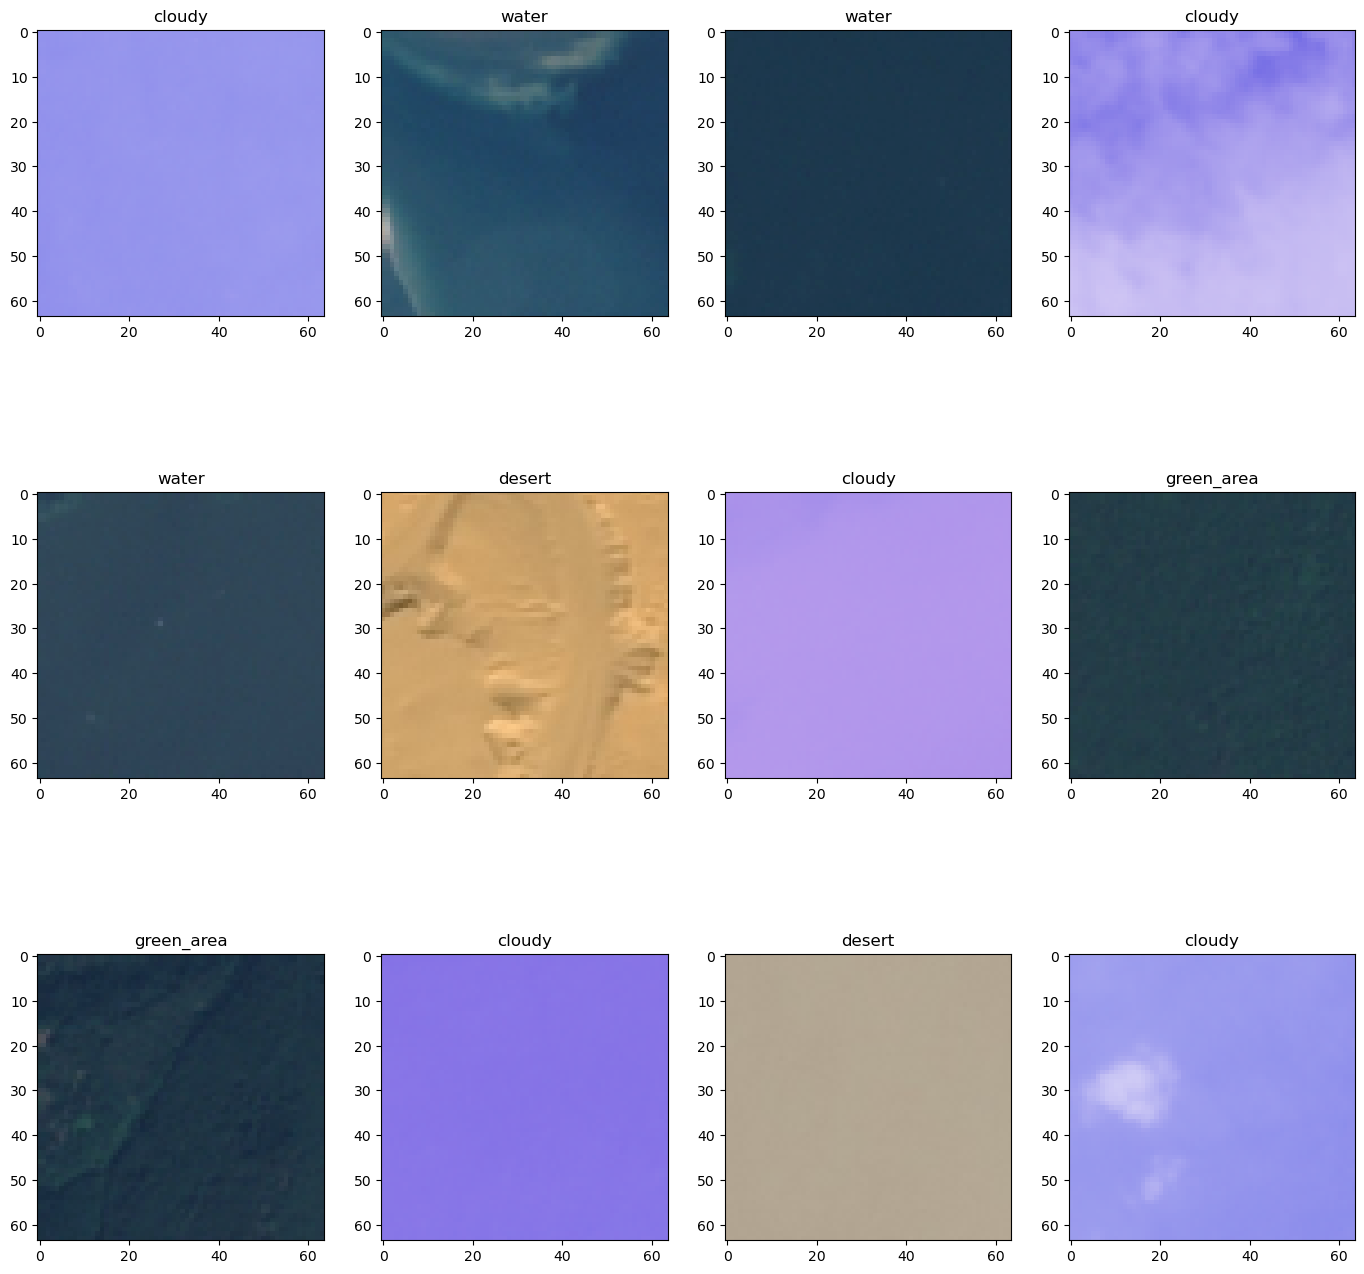

In [18]:
plt.figure(figsize=(17,17))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X[i])
    if label[i] == 0:
        plt.title('cloudy')
    elif label[i] == 1:
        plt.title('desert')
    elif label[i] == 2:
        plt.title('green_area')
    elif label[i] == 3:
        plt.title('water')

In [19]:
#Datatype of X and label
print(type(X))
print(type(label))

<class 'numpy.ndarray'>
<class 'list'>


In [20]:
#Convert the label to numpy array
y = np.array(label)

### Train Test Split

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)

### Create Keras Sequential model with 2 convolution layer, Flatten and a Hidden layer

In [24]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16,(3,3),activation='relu',input_shape=(64,64,3)),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Conv2D(16,(3,3),activation='relu'),
    keras.layers.MaxPool2D(2,2),

    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dense(4,activation='softmax')
])

C:\Users\User\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile our model

In [26]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         200,768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 203,796 (796.08 KB)

 Trainable params: 203,796 (796.08 KB)

 Non-trainable params: 0 (0.00 B)

### Train our model with X_train,y_train

In [29]:
model.fit(X_train,y_train,epochs=20,batch_size=32,validation_split=0.2)

Epoch 1/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.7419 - loss: 0.4860 - val_accuracy: 0.8391 - val_loss: 0.3183
Epoch 2/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8790 - loss: 0.2626 - val_accuracy: 0.8790 - val_loss: 0.2428
Epoch 3/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.9020 - loss: 0.2072 - val_accuracy: 0.9245 - val_loss: 0.1575
Epoch 4/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9167 - loss: 0.1837 - val_accuracy: 0.9223 - val_loss: 0.1985
Epoch 5/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9240 - loss: 0.1727 - val_accuracy: 0.9467 - val_loss: 0.1335
Epoch 6/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - accuracy: 0.9273 - loss: 0.1730 - val_accuracy: 0.9467 - val_loss: 0.1319
Epoch 7/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9267 - loss: 0.1669 - val_accuracy: 0.9534 - val_loss: 0.1410
Epoch 8/20
113/113 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.9381 - loss: 0.1458 - val_acc

### Evaluate our model

In [31]:
model.evaluate(X_train,y_train)

141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9574 - loss: 0.1106


[0.11058349907398224, 0.9573712348937988]

### Make predictions with X_test

In [33]:
prediction = model.predict(X_test)

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


In [34]:
prediction[:5]

array([[1.0000000e+00, 2.1690873e-13, 3.0569017e-10, 3.9869848e-12],
       [9.9999964e-01, 4.3075066e-19, 3.1849171e-07, 1.1212284e-16],
       [1.2775679e-07, 9.9997807e-01, 5.7605145e-12, 2.1757174e-05],
       [2.2066213e-05, 4.8173053e-05, 5.8382111e-06, 9.9992394e-01],
       [3.5384335e-07, 4.5063490e-07, 9.1692948e-01, 8.3069794e-02]],
      dtype=float32)

### Use np.argmax to fetch indices of max element of array

In [36]:
y_pred = [np.argmax(i) for i in prediction]

In [37]:
y_pred[:10]

[0, 0, 1, 3, 2, 3, 3, 3, 1, 1]

### Plot X_test with label from our prediction

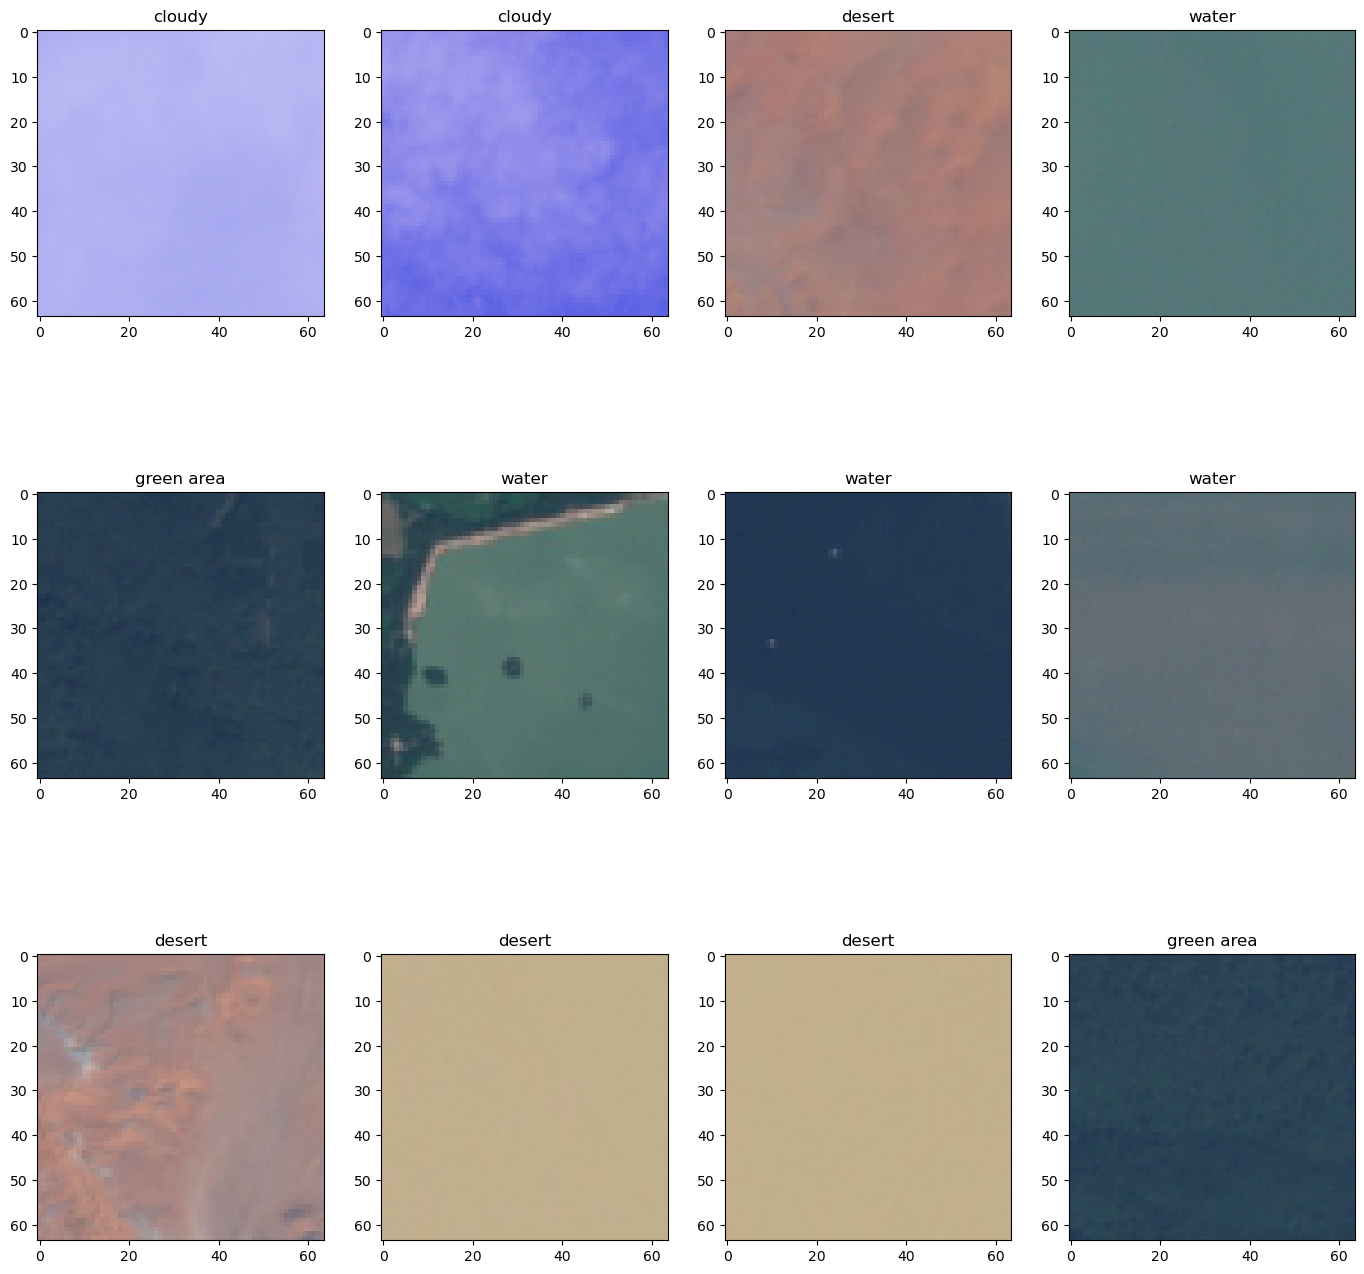

In [39]:
plt.figure(figsize=(17,17))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if y_pred[i] == 0:
        plt.title('cloudy')
    elif y_pred[i] == 1:
        plt.title('desert')
    elif y_pred[i] == 2:
        plt.title('green area')
    elif y_pred[i] == 3:
        plt.title('water')

### Plot confusion matrix on a heatmap

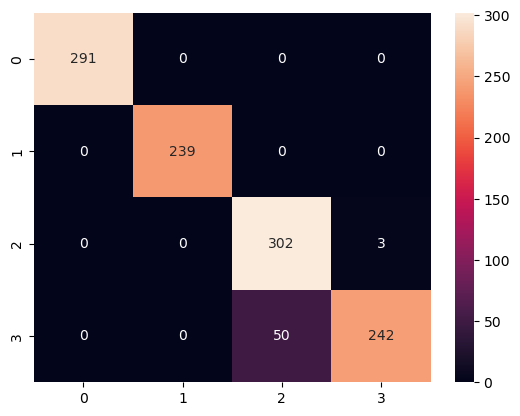

In [41]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')
plt.show()

### Classification Report

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       291
           1       1.00      1.00      1.00       239
           2       0.86      0.99      0.92       305
           3       0.99      0.83      0.90       292

    accuracy                           0.95      1127
   macro avg       0.96      0.95      0.96      1127
weighted avg       0.96      0.95      0.95      1127

